# AI Impact on University Students - Data Analysis

Analyzing how GenAI tools affect student performance and study habits

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print('Libraries loaded')

Libraries loaded


## 2. Load Dataset

In [ ]:
df = pd.read_csv('/Workspace/Users/guruvendra47@gmail.com/Class_Project/aistudent_raw_data.csv')
print(f'Loaded {len(df):,} rows')
df.head()

Loaded 50,000 rows


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


## 3. Data Overview

In [ ]:
print(f'Dataset shape: {df.shape}')
print(f'\nColumn names and types:')
print(df.dtypes)
print(f'\nMemory usage:')
print(df.memory_usage(deep=True).sum() / 1024**2, 'MB')

Dataset shape: (50000, 18)

Column names and types:
Student_ID                       int64
Major_Category                  object
Year_of_Study                 category
Pre_Semester_GPA               float64
Weekly_GenAI_Hours             float64
Primary_Use_Case                object
Prompt_Engineering_Skill        object
Tool_Diversity                   int64
Paid_Subscription                 bool
Traditional_Study_Hours        float64
Perceived_AI_Dependency          int64
Institutional_Policy            object
Anxiety_Level_During_Exams       int64
Post_Semester_GPA              float64
Skill_Retention_Score          float64
Burnout_Risk_Level              object
GPA_Change                     float64
GPA_Improved                      bool
dtype: object

Memory usage:
18.395174980163574 MB


## 4. Data Quality Assessment

In [ ]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nDuplicates: {df.duplicated().sum()}')
print(f'\nShape: {df.shape}')

Missing values:
Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

Duplicates: 0

Shape: (50000, 16)


## 5. Data Cleaning

In [ ]:
# remove duplicates if any
df = df.drop_duplicates()

# strip whitespace from text columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

print(f'Clean dataset: {len(df):,} rows')

Clean dataset: 50,000 rows


## 6. Feature Engineering

In [ ]:
# calculate GPA change
df['GPA_Change'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']

# did GPA improve
df['GPA_Improved'] = df['GPA_Change'] > 0

# make year ordered
year_order = ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate']
df['Year_of_Study'] = pd.Categorical(df['Year_of_Study'], categories=year_order, ordered=True)

print('Features created')

Features created


## 7. Exploratory Data Analysis (EDA)

### 7.1 Descriptive Statistics

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['Student_ID'], errors='ignore')
numeric_cols.describe().round(2)

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,GPA_Change
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,3.15,8.43,2.80,11.21,3.51,4.27,3.35,75.80,0.20
std,0.48,8.27,1.19,5.16,1.82,2.14,0.50,13.28,0.19
min,1.18,0.00,1.00,1.00,1.00,1.00,1.00,10.78,-0.92
25%,2.83,2.39,2.00,7.56,2.00,3.00,3.02,66.82,0.09
50%,3.21,5.80,3.00,11.18,3.00,4.00,3.42,76.00,0.20
75%,3.52,11.72,4.00,14.71,5.00,6.00,3.75,85.19,0.33
max,4.00,40.00,5.00,35.86,10.00,10.00,4.00,100.00,1.01


In [ ]:
print('Key Statistics:')
print(f"Average Pre-GPA: {df['Pre_Semester_GPA'].mean():.2f}")
print(f"Average Post-GPA: {df['Post_Semester_GPA'].mean():.2f}")
print(f"Average GPA Change: {df['GPA_Change'].mean():.2f}")
print(f"Students who improved: {df['GPA_Improved'].sum():,} ({df['GPA_Improved'].mean()*100:.1f}%)")
print(f"\nAverage GenAI hours/week: {df['Weekly_GenAI_Hours'].mean():.1f}")
print(f"Average traditional study hours: {df['Traditional_Study_Hours'].mean():.1f}")

Key Statistics:
Average Pre-GPA: 3.15
Average Post-GPA: 3.35
Average GPA Change: 0.20
Students who improved: 43,759 (87.5%)

Average GenAI hours/week: 8.4
Average traditional study hours: 11.2


### 7.2 Univariate Analysis

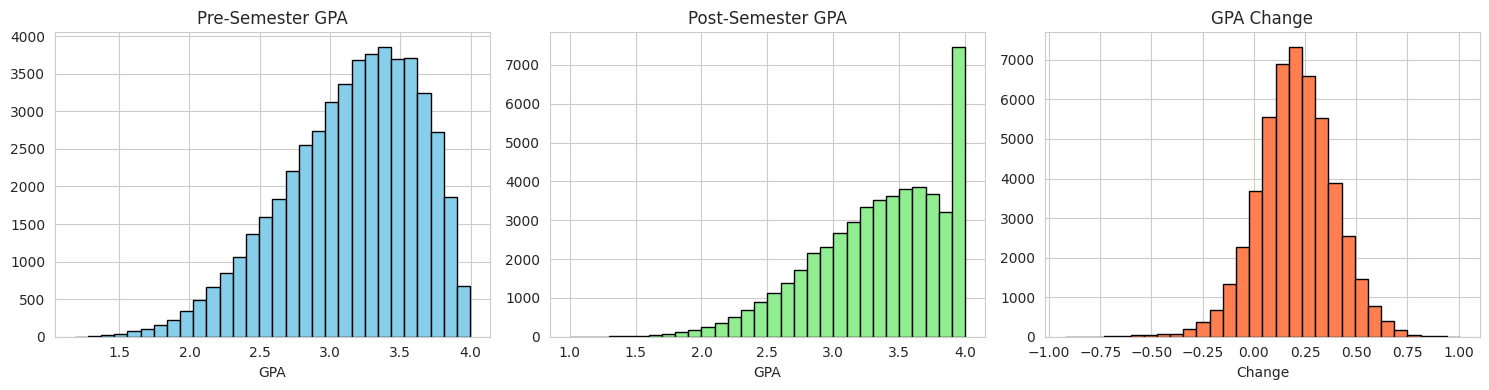

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['Pre_Semester_GPA'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Pre-Semester GPA')
axes[0].set_xlabel('GPA')

axes[1].hist(df['Post_Semester_GPA'], bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Post-Semester GPA')
axes[1].set_xlabel('GPA')

axes[2].hist(df['GPA_Change'], bins=30, color='coral', edgecolor='black')
axes[2].set_title('GPA Change')
axes[2].set_xlabel('Change')

plt.tight_layout()
plt.show()

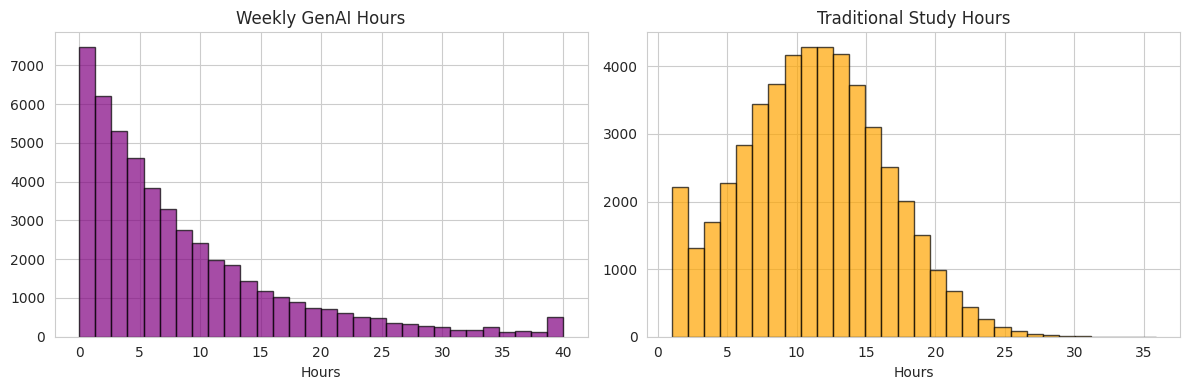

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Weekly_GenAI_Hours'], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[0].set_title('Weekly GenAI Hours')
axes[0].set_xlabel('Hours')

axes[1].hist(df['Traditional_Study_Hours'], bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[1].set_title('Traditional Study Hours')
axes[1].set_xlabel('Hours')

plt.tight_layout()
plt.show()

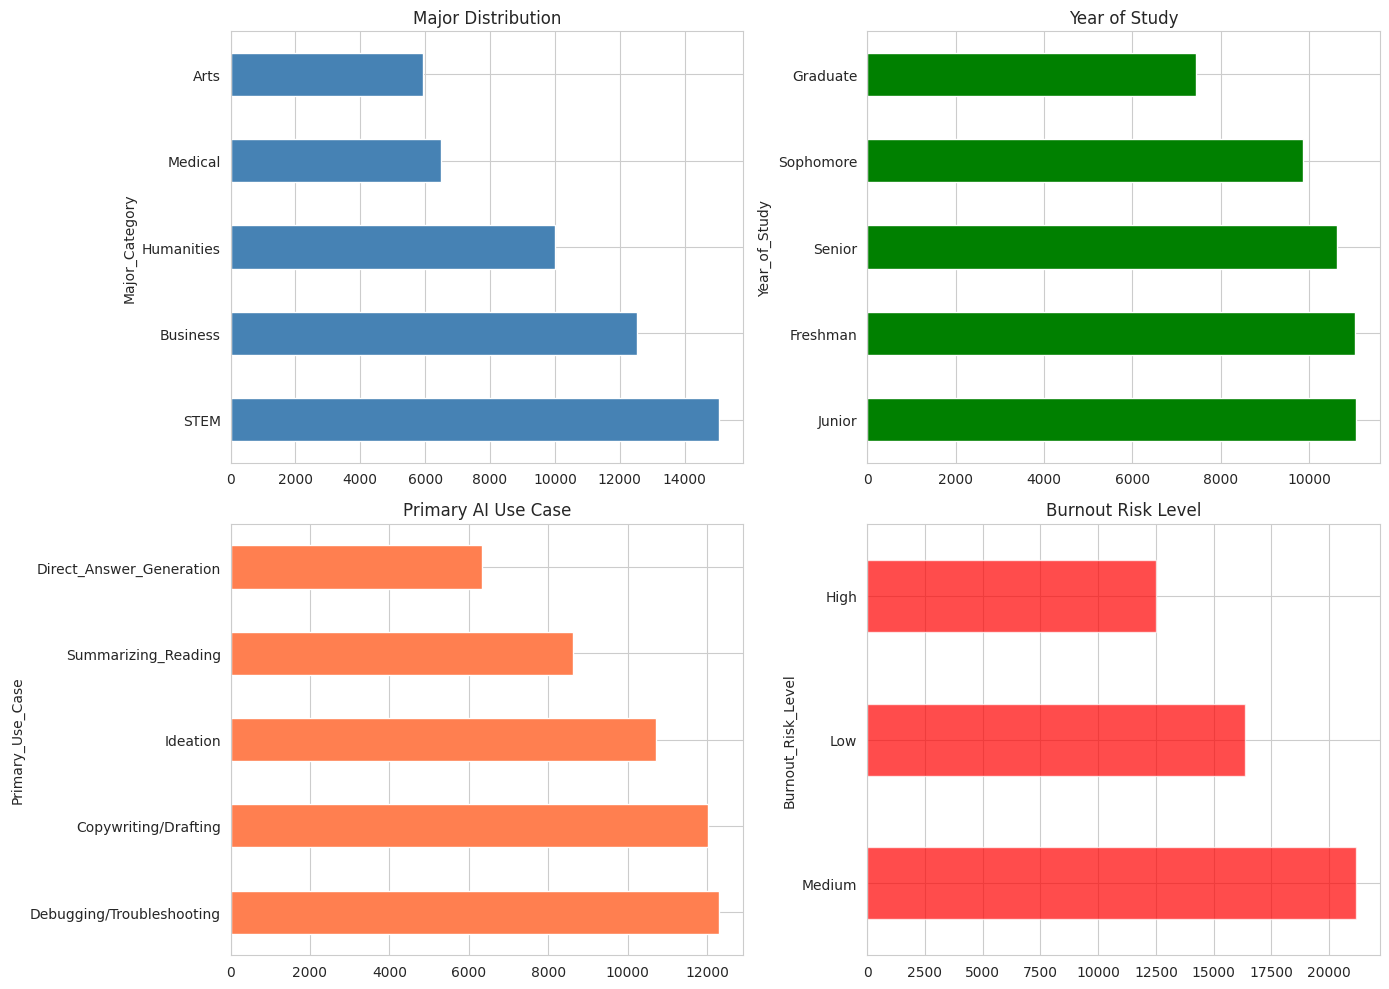

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# major
df['Major_Category'].value_counts().plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Major Distribution')

# year of study
df['Year_of_Study'].value_counts().plot(kind='barh', ax=axes[0,1], color='green')
axes[0,1].set_title('Year of Study')

# primary use case
df['Primary_Use_Case'].value_counts().plot(kind='barh', ax=axes[1,0], color='coral')
axes[1,0].set_title('Primary AI Use Case')

# burnout risk
df['Burnout_Risk_Level'].value_counts().plot(kind='barh', ax=axes[1,1], color='red', alpha=0.7)
axes[1,1].set_title('Burnout Risk Level')

plt.tight_layout()
plt.show()

### 7.3 Bivariate Analysis

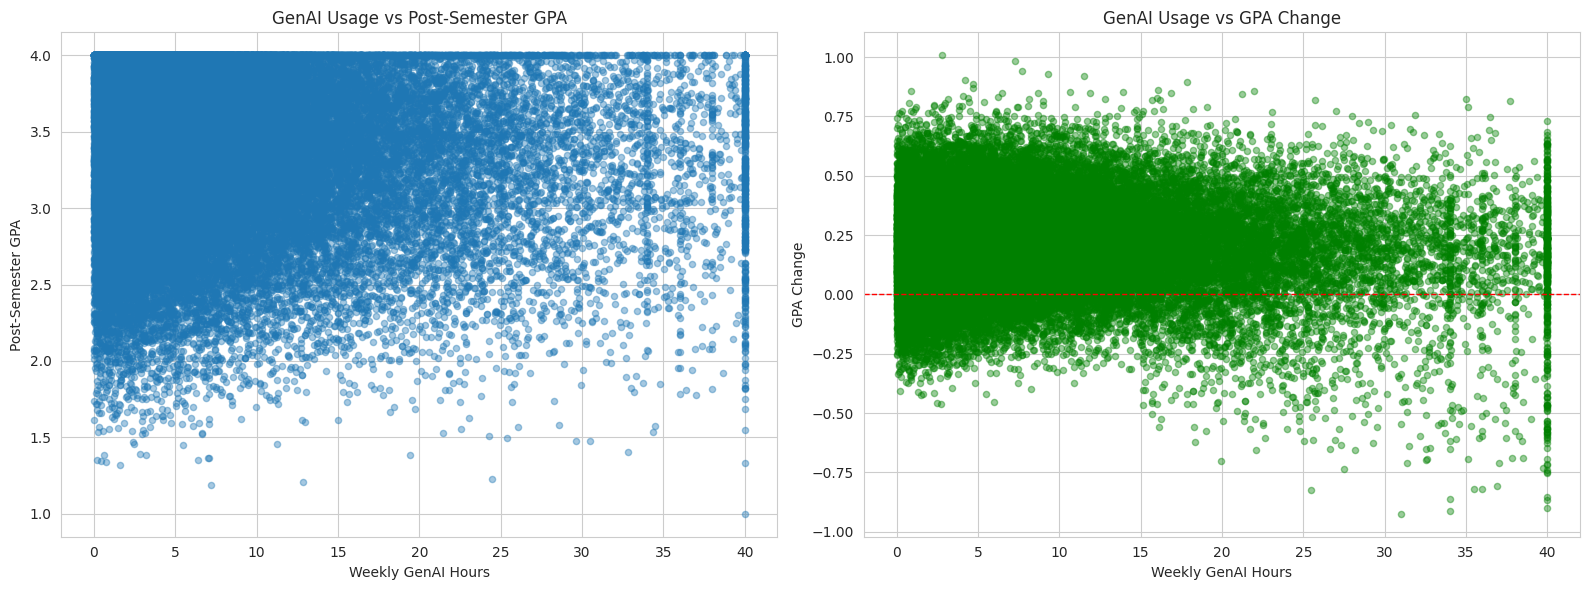


Correlations:
                    Weekly_GenAI_Hours  Post_Semester_GPA  GPA_Change
Weekly_GenAI_Hours            1.000000          -0.018600   -0.046479
Post_Semester_GPA            -0.018600           1.000000    0.277146
GPA_Change                   -0.046479           0.277146    1.000000


In [ ]:
# does more GenAI usage lead to better GPA?
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df['Weekly_GenAI_Hours'], df['Post_Semester_GPA'], alpha=0.4, s=20)
axes[0].set_xlabel('Weekly GenAI Hours')
axes[0].set_ylabel('Post-Semester GPA')
axes[0].set_title('GenAI Usage vs Post-Semester GPA')

axes[1].scatter(df['Weekly_GenAI_Hours'], df['GPA_Change'], alpha=0.4, s=20, color='green')
axes[1].set_xlabel('Weekly GenAI Hours')
axes[1].set_ylabel('GPA Change')
axes[1].set_title('GenAI Usage vs GPA Change')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

corr = df[['Weekly_GenAI_Hours', 'Post_Semester_GPA', 'GPA_Change']].corr()
print('\nCorrelations:')
print(corr)

                           Avg_GPA_Change  Avg_Post_GPA  Count
Primary_Use_Case                                              
Debugging/Troubleshooting           0.249         3.396  12295
Copywriting/Drafting                0.200         3.335  12011
Ideation                            0.200         3.344  10721
Summarizing_Reading                 0.197         3.350   8633
Direct_Answer_Generation            0.133         3.294   6340


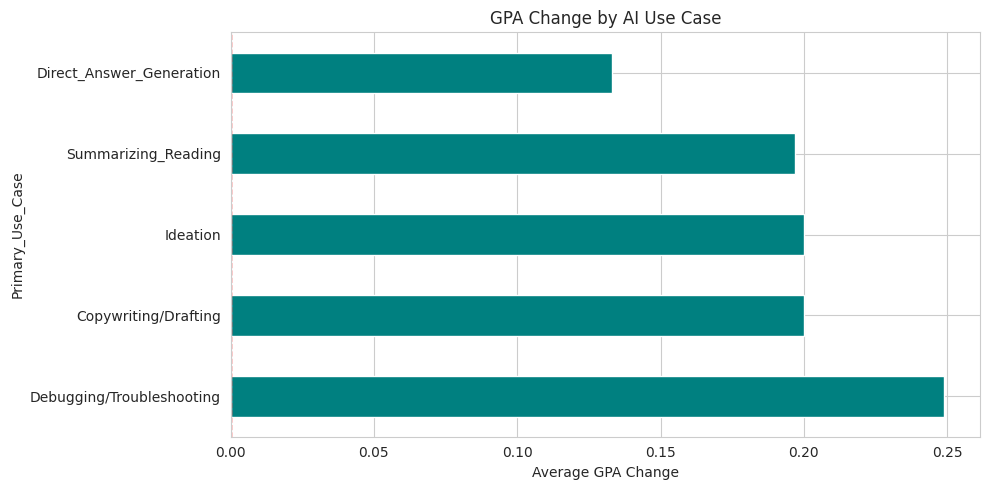

In [ ]:
# which use cases help students most
use_case_gpa = df.groupby('Primary_Use_Case').agg({
    'GPA_Change': 'mean',
    'Post_Semester_GPA': 'mean',
    'Student_ID': 'count'
}).round(3)

use_case_gpa.columns = ['Avg_GPA_Change', 'Avg_Post_GPA', 'Count']
use_case_gpa = use_case_gpa.sort_values('Avg_GPA_Change', ascending=False)

print(use_case_gpa)

fig, ax = plt.subplots(figsize=(10, 5))
use_case_gpa['Avg_GPA_Change'].plot(kind='barh', ax=ax, color='teal')
ax.set_xlabel('Average GPA Change')
ax.set_title('GPA Change by AI Use Case')
ax.axvline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

                    Avg_GenAI_Hours  Avg_Trad_Hours  Avg_GPA_Change  Count
Burnout_Risk_Level                                                        
High                          15.21           10.08            0.20  12487
Low                            4.64           11.97            0.20  16369
Medium                         7.35           11.29            0.21  21144


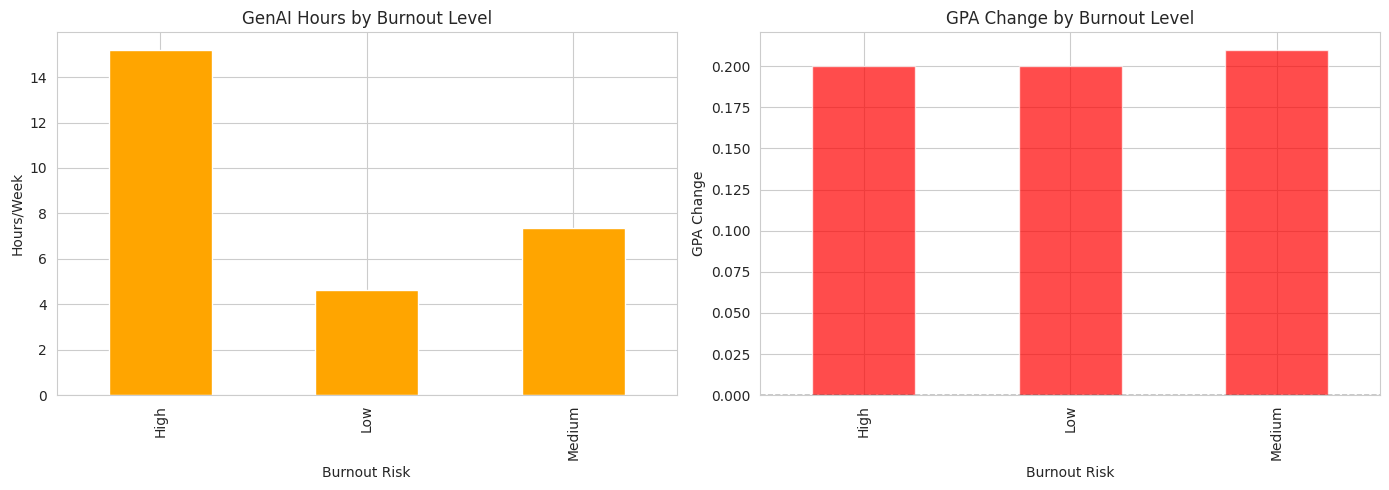

In [ ]:
# burnout vs GenAI usage
burnout_analysis = df.groupby('Burnout_Risk_Level').agg({
    'Weekly_GenAI_Hours': 'mean',
    'Traditional_Study_Hours': 'mean',
    'GPA_Change': 'mean',
    'Student_ID': 'count'
}).round(2)

burnout_analysis.columns = ['Avg_GenAI_Hours', 'Avg_Trad_Hours', 'Avg_GPA_Change', 'Count']
print(burnout_analysis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

burnout_analysis['Avg_GenAI_Hours'].plot(kind='bar', ax=axes[0], color='orange')
axes[0].set_title('GenAI Hours by Burnout Level')
axes[0].set_ylabel('Hours/Week')
axes[0].set_xlabel('Burnout Risk')

burnout_analysis['Avg_GPA_Change'].plot(kind='bar', ax=axes[1], color='red', alpha=0.7)
axes[1].set_title('GPA Change by Burnout Level')
axes[1].set_ylabel('GPA Change')
axes[1].set_xlabel('Burnout Risk')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

                          Avg_Post_GPA  Avg_GPA_Change  Avg_GenAI_Hours  Count
Prompt_Engineering_Skill                                                      
Advanced                         3.389           0.248            8.694  13809
Beginner                         3.334           0.185            8.286  18495
Intermediate                     3.334           0.187            8.367  17696


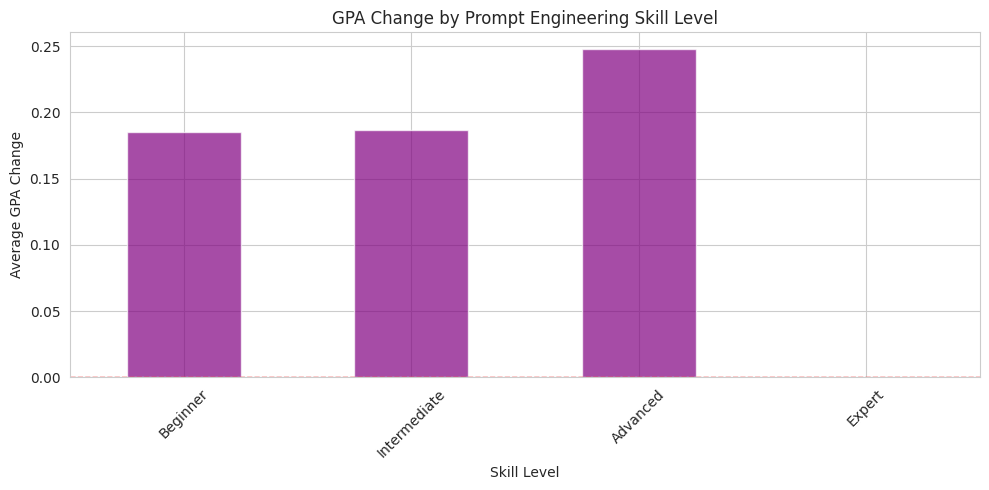

In [ ]:
# does prompt engineering skill matter
skill_analysis = df.groupby('Prompt_Engineering_Skill').agg({
    'Post_Semester_GPA': 'mean',
    'GPA_Change': 'mean',
    'Weekly_GenAI_Hours': 'mean',
    'Student_ID': 'count'
}).round(3)

skill_analysis.columns = ['Avg_Post_GPA', 'Avg_GPA_Change', 'Avg_GenAI_Hours', 'Count']
print(skill_analysis)

fig, ax = plt.subplots(figsize=(10, 5))
skill_order = ['Beginner', 'Intermediate', 'Advanced', 'Expert']
skill_data = skill_analysis.reindex(skill_order)['Avg_GPA_Change']
skill_data.plot(kind='bar', ax=ax, color='purple', alpha=0.7)
ax.set_title('GPA Change by Prompt Engineering Skill Level')
ax.set_ylabel('Average GPA Change')
ax.set_xlabel('Skill Level')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# differences by major
major_analysis = df.groupby('Major_Category').agg({
    'Weekly_GenAI_Hours': 'mean',
    'GPA_Change': 'mean',
    'Post_Semester_GPA': 'mean',
    'Student_ID': 'count'
}).round(3)

major_analysis.columns = ['Avg_GenAI_Hours', 'Avg_GPA_Change', 'Avg_Post_GPA', 'Count']
major_analysis = major_analysis.sort_values('Avg_GPA_Change', ascending=False)
print(major_analysis)

                Avg_GenAI_Hours  Avg_GPA_Change  Avg_Post_GPA  Count
Major_Category                                                      
STEM                     10.489           0.217         3.363  15059
Medical                   7.547           0.201         3.353   6476
Humanities                6.770           0.198         3.346   9994
Arts                      7.272           0.197         3.344   5933
Business                  8.276           0.194         3.336  12538


               Avg_GenAI_Hours  Avg_GPA_Change  Avg_Post_GPA  Count
Year_of_Study                                                      
Freshman                 8.447           0.132         3.278  11031
Sophomore                8.446           0.177         3.327   9860
Junior                   8.376           0.226         3.372  11045
Senior                   8.459           0.243         3.390  10634
Graduate                 8.406           0.252         3.392   7430


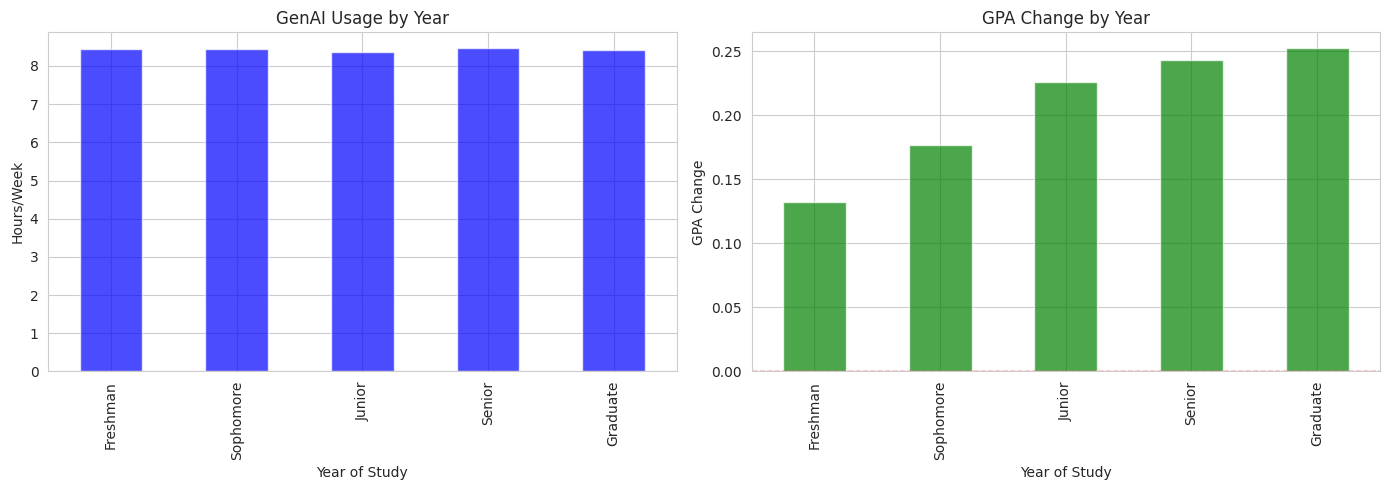

In [ ]:
# by year of study
year_analysis = df.groupby('Year_of_Study').agg({
    'Weekly_GenAI_Hours': 'mean',
    'GPA_Change': 'mean',
    'Post_Semester_GPA': 'mean',
    'Student_ID': 'count'
}).round(3)

year_analysis.columns = ['Avg_GenAI_Hours', 'Avg_GPA_Change', 'Avg_Post_GPA', 'Count']
print(year_analysis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

year_analysis['Avg_GenAI_Hours'].plot(kind='bar', ax=axes[0], color='blue', alpha=0.7)
axes[0].set_title('GenAI Usage by Year')
axes[0].set_ylabel('Hours/Week')
axes[0].set_xlabel('Year of Study')

year_analysis['Avg_GPA_Change'].plot(kind='bar', ax=axes[1], color='green', alpha=0.7)
axes[1].set_title('GPA Change by Year')
axes[1].set_ylabel('GPA Change')
axes[1].set_xlabel('Year of Study')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

### 7.4 Multivariate Analysis

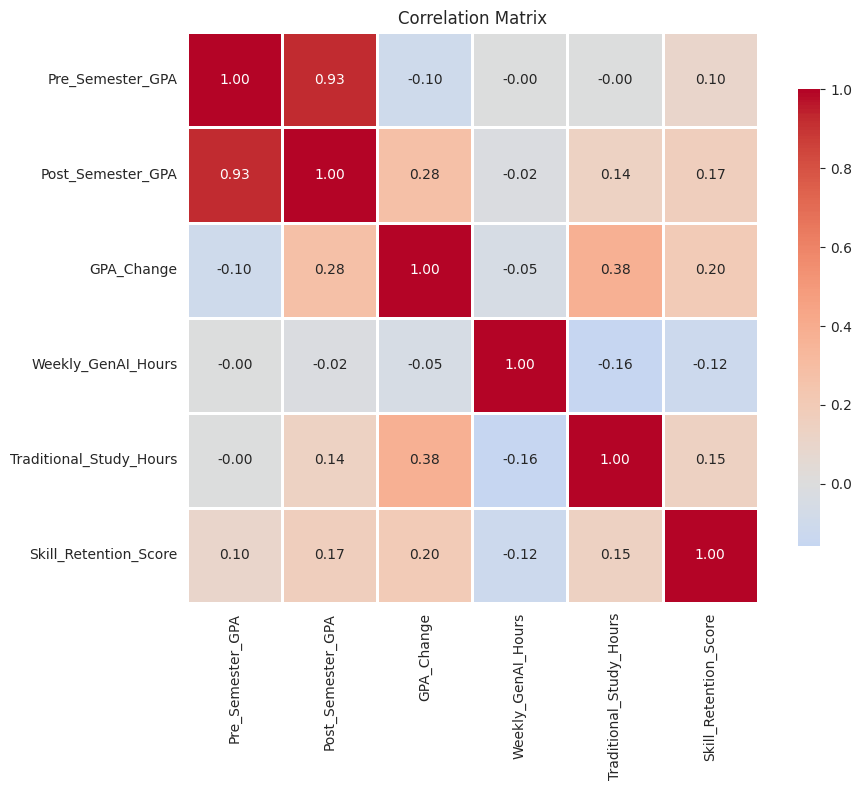

In [ ]:
# correlation between numeric variables
corr_cols = ['Pre_Semester_GPA', 'Post_Semester_GPA', 'GPA_Change',
             'Weekly_GenAI_Hours', 'Traditional_Study_Hours',
             'Skill_Retention_Score']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Summary of Findings

### What We Found

**Overall Impact:**
* 87.5% of students improved their GPA after using GenAI tools
* Average GPA increased from 3.15 to 3.35 (0.20 improvement)
* Students use GenAI 8.4 hours per week on average

**Most Effective Use Cases:**
* Debugging and troubleshooting gave the best results (+0.249 GPA change)
* Copywriting and ideation also helped (+0.20)
* Just getting direct answers showed the least improvement (+0.133)

**Skill Level Matters:**
* Advanced users saw +0.248 GPA improvement
* Beginners only saw +0.185 improvement
* Learning how to use GenAI properly makes a big difference

**Interesting Patterns:**
* STEM majors use GenAI the most (10.5 hours/week) and benefit the most
* Graduate students benefit more than freshmen
* High burnout students use 3x more GenAI but don't see better results
* More GenAI hours doesn't always mean better grades (negative correlation)

**Burnout Observation:**
* Students at high burnout risk use GenAI 15.2 hours/week
* Low burnout students only use 4.6 hours/week
* All groups show similar GPA improvements regardless of burnout level



```
## This is formatted as code
```

### Dashboard


**Main stats to show:**
- How much GPA improved overall
- Avg hours students spend on GenAI
- % of students who actually got better

**Charts & graphs:**
- Before/after GPA distributions side by side
- How different majors & years use GenAI
- Which use cases work best (ranked)
- Does burnout relate to usage?
- Skill level vs performance gains

**Filters:**
- Filter by major, year, use case
- Compare groups
- See patterns across skill levels

Should help figure out which strategies actually work for different student types.

## 8. Save Cleaned Data

In [ ]:
# save the cleaned dataset with new features
output_path = '/Workspace/Users/guruvendra47@gmail.com/Class_Project/ai_student_cleaned.csv'
df.to_csv(output_path, index=False)
print(f'Cleaned dataset saved to: {output_path}')
print(f'Final shape: {df.shape}')
print(f'Columns: {df.shape[1]}')

Cleaned dataset saved to: /Workspace/Users/guruvendra47@gmail.com/Class_Project/ai_student_cleaned.csv
Final shape: (50000, 18)
Columns: 18
